# Geocoding

This notebook geocodes the violation location and respondent home addresses using NYC's GeoSupport geocoder (https://www.nyc.gov/content/planning/pages/resources/geocoding/geosupport-desktop-edition). Addresses are built from the original OATH data and cleaned before being sent through the geocoder using async batching to reduce runtime. The matched geocoded addresses are then classified in the following categories by comparing the matched address feature to the original address feature:

**For violations**
* `0` for no match
* `1` for an exact match
* `2` for a fallback match on the same street
* `3` for a fallback match in the same neighborhood
* `4` for a fallback match with the same ZIP code
* `5` for a fallback match in the same borough
* `nan` if the matched address is something else

**For respondents**
* `0` for no match
* `1` for an exact match
* `2` for a fallback match with the same house number
* `3` for a fallback match with the zame ZIP code
* `4` for a fallback match in the same borough
* `nan` if the matched address is something else


In [ ]:
# Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys, os
sys.path.append(os.path.abspath("..")) 
from src.addresses import *
from src.geocoding import *

FIGURES_DIR = "../outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)

DATA_DIR = "...data/processed"
os.makedirs(DATA_DIR, exist_ok=True)

#Load df
violations_df_full = pd.read_csv(f"{DATA_DIR}/violations_df_full.csv")


/var/folders/dz/r3jh38h95rs7sxsc47pyxs980000gn/T/ipykernel_85973/2729617963.py:20: DtypeWarning: Columns (0: ticket_number, 1: respondent_address_zip_code, 2: charge_2_code, 3: charge_2_code_section, 4: charge_2_code_description) have mixed types. Specify dtype option on import or set low_memory=False.
  violations_df_full = pd.read_csv(f"{DATA_DIR}/violations_df_full.csv")


**Building and Cleaning Full Address Strings**

In [ ]:
# Building full address
violations_df_full['violation_address'] = violations_df_full.apply(build_violation_address, axis=1)
violations_df_full['respondent_address'] = violations_df_full.apply(build_respondent_address, axis=1)

# Cleaning full address
violations_df_full['violation_address'] = violations_df_full['violation_address'].apply(clean_address)
violations_df_full['respondent_address'] = violations_df_full['respondent_address'].apply(clean_address)

**Geocoding**

In [ ]:
# Deduplicating addresses to geocode
unique_violation_addresses = violations_df_full['violation_address'].drop_duplicates().to_frame()
unique_respondent_addresses = violations_df_full['respondent_address'].drop_duplicates().to_frame()

print("Number of unique violation addresses:", len(unique_violation_addresses))
print("\nNumber of unique respondent addresses:", len(unique_respondent_addresses), "\n")

# Geocoding
violation_geocoded  = await geocode_addresses(
    unique_violation_addresses["violation_address"].tolist(),
    VIOLATION_CHECKPOINT
)

respondent_geocoded = await geocode_addresses(
    unique_respondent_addresses["respondent_address"].tolist(),
    RESPONDENT_CHECKPOINT
)

print("\n\nGeocoding complete.")

Number of unique violation addresses: 38701

Number of unique respondent addresses: 14532 

Total:       38701
Already done:0
Remaining:   38701
  [17:09:59] Checkpointed 500/38701
  [17:11:53] Checkpointed 1000/38701
  [17:12:59] Checkpointed 1500/38701
  [17:14:34] Checkpointed 2000/38701
  [17:15:58] Checkpointed 2500/38701
  [17:17:51] Checkpointed 3000/38701
  [17:19:49] Checkpointed 3500/38701
  [17:21:29] Checkpointed 4000/38701
  [17:23:57] Checkpointed 4500/38701
  [17:25:53] Checkpointed 5000/38701
  [17:26:59] Checkpointed 5500/38701
  [17:28:32] Checkpointed 6000/38701
  [17:30:11] Checkpointed 6500/38701
  [17:31:58] Checkpointed 7000/38701
  [17:33:35] Checkpointed 7500/38701
  [17:35:42] Checkpointed 8000/38701
  [17:37:00] Checkpointed 8500/38701
  [17:38:59] Checkpointed 9000/38701
  [17:40:56] Checkpointed 9500/38701
  [17:43:01] Checkpointed 10000/38701
  [17:44:40] Checkpointed 10500/38701
  [17:45:52] Checkpointed 11000/38701
  [17:47:37] Checkpointed 11500/38701
 

In [39]:
# Saving a sample

SAMPLE_DIR = "../data/sample"
os.makedirs(SAMPLE_DIR, exist_ok=True)
violation_geocoded.sample(100).to_csv(f"{SAMPLE_DIR}/violation_geocoded_sample.csv", index=False)

**Flagging Levels of Geocoding Precision**

In [6]:
# Creating datasets to compare original address features with matched address features

violation_rename = {col: f'v_matched_{col}' for col in violation_geocoded.columns}
violation_geocoded_comparison = violation_geocoded.rename(columns=violation_rename)

respondent_rename = {col: f'r_matched_{col}' for col in respondent_geocoded.columns}
respondent_geocoded_comparison = respondent_geocoded.rename(columns=respondent_rename)

# Merging with original features

violation_geocoded_comparison = pd.merge(
    violation_geocoded_comparison,
    violations_df_full[['violation_address', 'violation_location_house', 'violation_location_street_name', 'violation_location_borough',
                        'violation_location_city', 'violation_location_zip_code', 'violation_location_state_name']],
    how = 'left',
    right_on = 'violation_address',
    left_on = 'v_matched_input_address'
)

respondent_geocoded_comparison = pd.merge(
    respondent_geocoded_comparison,
    violations_df_full[['respondent_address', 'respondent_address_house', 'respondent_address_borough', 'respondent_address_zip_code']],
    how = 'left',
    right_on = 'respondent_address',
    left_on = 'r_matched_input_address'
)


In [7]:
# Creating geocoded tiers

# Violation Tier
conditions_v = [
    violation_geocoded_comparison['v_matched_match_type'].isna() | (violation_geocoded_comparison['v_matched_match_type'] == 'nan'),
    violation_geocoded_comparison['v_matched_match_type'] == 'exact',
    violation_geocoded_comparison['v_matched_street'].str.upper() == violation_geocoded_comparison['violation_location_street_name'].str.upper(),
    violation_geocoded_comparison['v_matched_neighbourhood'].str.upper() == violation_geocoded_comparison['violation_location_city'].str.upper(),
    violation_geocoded_comparison['v_matched_postalcode'] == violation_geocoded_comparison['violation_location_zip_code'].astype(str),
    violation_geocoded_comparison['v_matched_borough'].str.upper() == violation_geocoded_comparison['violation_location_borough'].str.upper(),
]
choices_v = [0, 1, 2, 3, 4, 5]

violation_geocoded_comparison['violation_geocoded_tier'] = np.select(conditions_v, choices_v, default=np.nan)

# Respondent Tier
conditions_r = [
    respondent_geocoded_comparison['r_matched_match_type'].isna() | (respondent_geocoded_comparison['r_matched_match_type'] == 'nan'),
    respondent_geocoded_comparison['r_matched_match_type'] == 'exact',
    respondent_geocoded_comparison['r_matched_housenumber'].str.upper() == respondent_geocoded_comparison['respondent_address_house'].str.upper(),
    respondent_geocoded_comparison['r_matched_postalcode'] == respondent_geocoded_comparison['respondent_address_zip_code'].astype(str),
    respondent_geocoded_comparison['r_matched_borough'].str.upper() == respondent_geocoded_comparison['respondent_address_borough'].str.upper(),
]
choices_r = [0, 1, 2, 3, 4]

respondent_geocoded_comparison['respondent_geocoded_tier'] = np.select(conditions_r, choices_r, default=np.nan)

In [ ]:
# Merging back to violations_df_full

# Dropping duplicates before merging
violation_geocoded_comparison = violation_geocoded_comparison.drop_duplicates(subset='v_matched_input_address', keep='last')
respondent_geocoded_comparison = respondent_geocoded_comparison.drop_duplicates(subset='r_matched_input_address', keep='last')

# Merge
violations_df_full = pd.merge(
    violations_df_full,
    violation_geocoded_comparison[['v_matched_label', 'v_matched_lat', 'v_matched_lon', 'violation_geocoded_tier', 'violation_address']],
    how = 'left',
    on  = 'violation_address'
).rename(columns = {"v_matched_label": "v_matched_address"})

violations_df_full = pd.merge(
    violations_df_full,
    respondent_geocoded_comparison[['r_matched_label', 'r_matched_lat', 'r_matched_lon', 'respondent_geocoded_tier', 'respondent_address']],
    how = 'left',
    on = 'respondent_address'
).rename(columns = {"r_matched_label": "r_matched_address"})

# Saving dataframe
violations_df_full.to_csv(f"{DATA_DIR}/violations_df_full.csv")

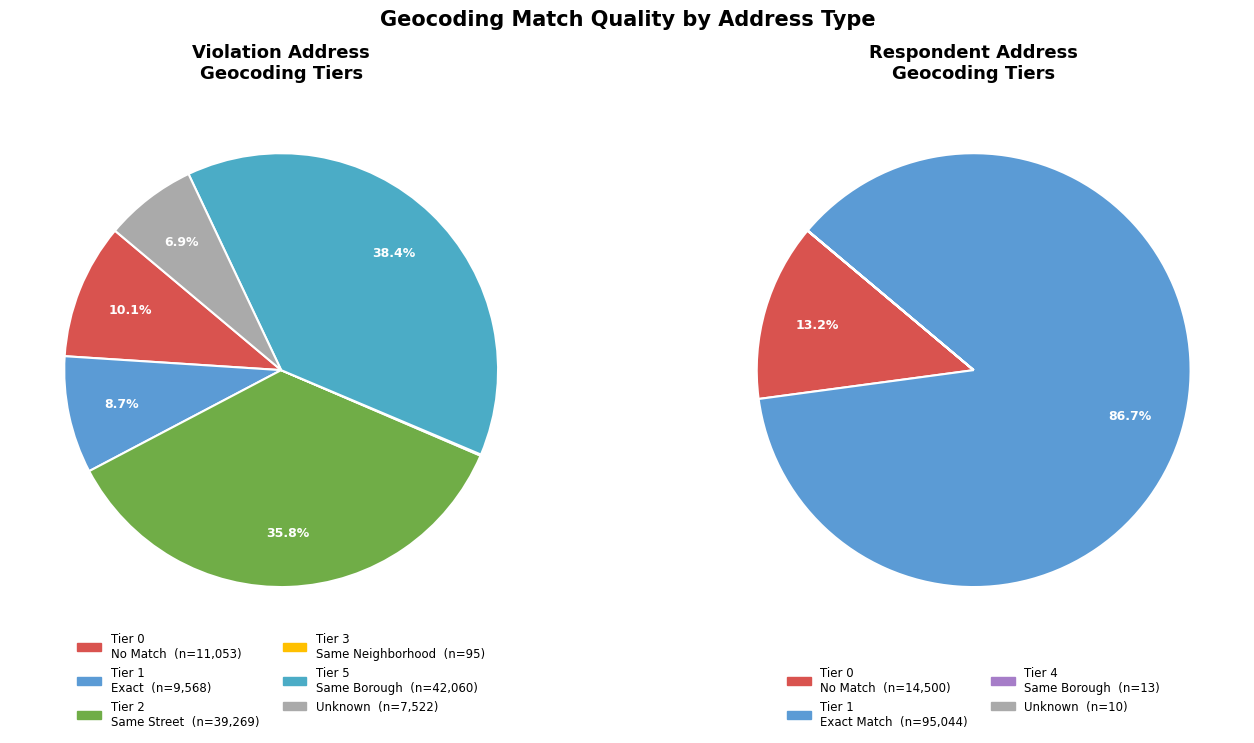

In [14]:
# Visualizing geocoding tier distribution

tier_labels_violation = {
    0: 'Tier 0\nNo Match',
    1: 'Tier 1\nExact',
    2: 'Tier 2\nSame Street',
    3: 'Tier 3\nSame Neighborhood',
    4: 'Tier 4\nSame Postal Code',
    5: 'Tier 5\nSame Borough'
}

tier_labels_respondent = {
    0: 'Tier 0\nNo Match',
    1: 'Tier 1\nExact Match',
    2: 'Tier 2\nNonexact, Same House Number',
    3: 'Tier 3\nSame Zip Code',
    4: 'Tier 4\nSame Borough',
    5: 'Tier 5\nUnknown'
}

colors = ['#d9534f', '#5b9bd5', '#70ad47', '#ffc000', '#a67dc8', '#4bacc6']

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

column_label_map = {
    'violation_geocoded_tier': tier_labels_violation,
    'respondent_geocoded_tier': tier_labels_respondent,
}

for ax, col, title in zip(
    axes,
    ['violation_geocoded_tier', 'respondent_geocoded_tier'],
    ['Violation Address\nGeocoding Tiers', 'Respondent Address\nGeocoding Tiers']
):
    tier_labels = column_label_map[col]

    counts = violations_df_full[col].value_counts(dropna=False).sort_index()
    tiers = [int(t) if not pd.isna(t) else -1 for t in counts.index]
    labels = [tier_labels.get(t, 'Unknown') for t in tiers]
    chart_colors = [colors[t] if t >= 0 else '#aaaaaa' for t in tiers]

    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=None,
        colors=chart_colors,
        autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
        startangle=140,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        pctdistance=0.75
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_fontweight('bold')
        at.set_color('white')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)

    legend_patches = [
        mpatches.Patch(color=chart_colors[i], label=f'{labels[i]}  (n={counts.values[i]:,})')
        for i in range(len(counts))
    ]
    ax.legend(handles=legend_patches, loc='lower center',
              bbox_to_anchor=(0.5, -0.18), fontsize=8.5, frameon=False, ncol=2)

fig.suptitle('Geocoding Match Quality by Address Type', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/geocoding_tiers.png", dpi=150, bbox_inches='tight')
plt.show()